## 1. Project and dataset path

In [10]:
from pathlib import Path

PROJECT_DIR = Path(r"D:/проекты/PowerGridReconfig")
DATASET_DIR = PROJECT_DIR / "data" / "_scratch" / "case118_bootstrap_v1_teacher_smoke_v1"
RAW_DIR = DATASET_DIR / "raw"

## 2. Imports

In [11]:
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 4. Canonical AC evaluation of generated scenarios

In [71]:
from grid_topology_ai.data import GridFMAdapter
from grid_topology_ai.power_flow.backend import GridFMPowerFlowBackend
from grid_topology_ai.search.teacher import safety_score

adapter = GridFMAdapter(RAW_DIR)
backend = GridFMPowerFlowBackend(adapter)

rows = []
n = 0 
scenario_limit = 100

for scenario_id in adapter.scenario_ids()[4660:4669+1]:
    if n == scenario_limit:
        break
    result = backend.run_power_flow(scenario_id, None)
    if result.success:
        state = result.next_state
        rows.append({
            "scenario_id": scenario_id,
            "J": safety_score(state),
            "max_loading_percent": state.metrics["max_loading_percent"],
            "num_overloaded": state.metrics["num_overloaded_branches"],
            "num_hard_overloaded": state.metrics["num_hard_overloaded_branches"],
        })
        n=n+1

scenarios = pd.DataFrame(rows)
scenarios.head(10)

,scenario_id,J,max_loading_percent,num_overloaded,num_hard_overloaded
0,4660,167.761639,123.248659,2,1
1,4661,160.277017,126.647774,3,1
2,4662,245.107194,140.777227,2,1
3,4663,204.562277,135.171237,2,1
4,4664,182.623578,132.189717,2,1
5,4665,246.581235,142.797312,1,1
6,4666,196.806745,134.217411,2,1
7,4667,224.151065,129.656458,5,1
8,4668,215.551198,138.364256,1,1
9,4669,199.269441,134.426648,2,1


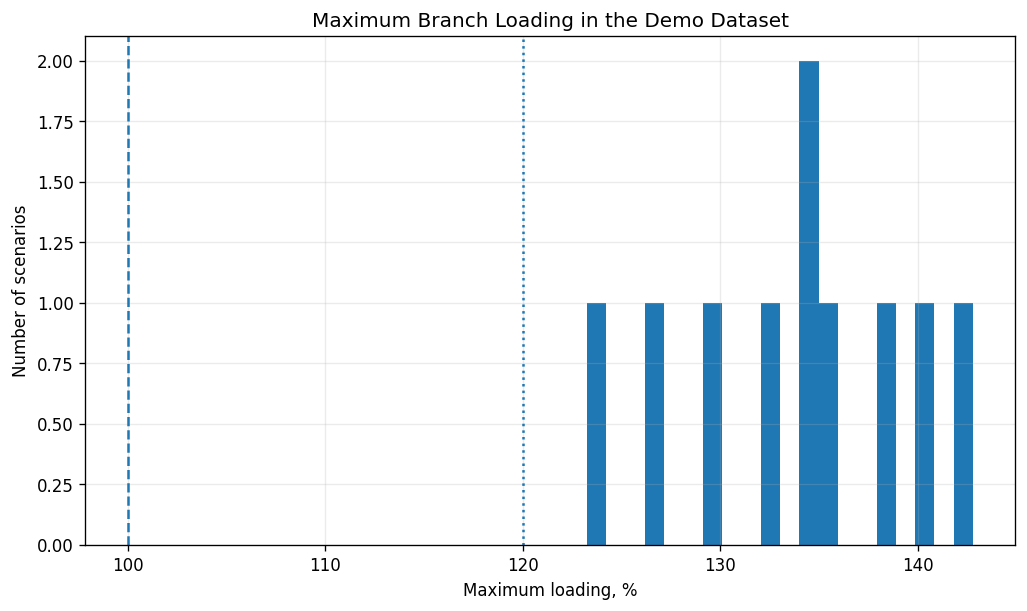

In [72]:
fig, ax = plt.subplots()
ax.hist(scenarios["max_loading_percent"], bins=20)
ax.axvline(100, linestyle="--")
ax.axvline(120, linestyle=":")
ax.set_title("Maximum Branch Loading in the Demo Dataset")
ax.set_xlabel("Maximum loading, %")
ax.set_ylabel("Number of scenarios")
plt.show()

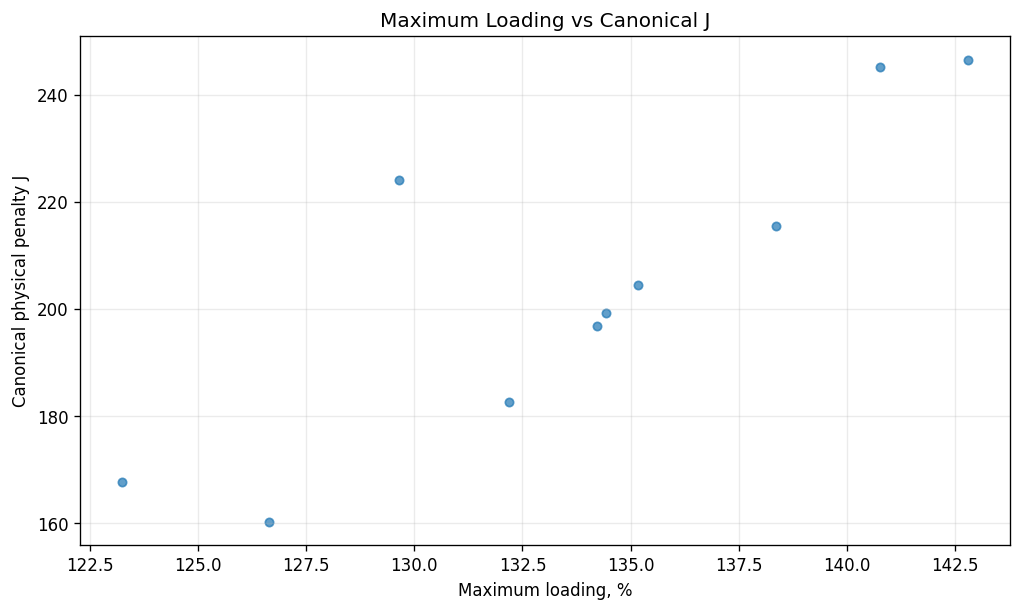

In [73]:
fig, ax = plt.subplots()
ax.scatter(scenarios["max_loading_percent"], scenarios["J"], s=25, alpha=0.7)
ax.set_title("Maximum Loading vs Canonical J")
ax.set_xlabel("Maximum loading, %")
ax.set_ylabel("Canonical physical penalty J")
plt.show()

## 5. Select one overloaded scenario

In [74]:
candidates = scenarios[
    (scenarios["num_overloaded"] > 0) &
    (scenarios["num_hard_overloaded"] == 0)
]

if candidates.empty:
    candidates = scenarios[scenarios["num_overloaded"] > 0]

scenario_id = int(candidates.sort_values("J", ascending=False).iloc[1]["scenario_id"])
scenario_id = int(4665)
scenarios[scenarios["scenario_id"] == scenario_id]

,scenario_id,J,max_loading_percent,num_overloaded,num_hard_overloaded
5,4665,246.581235,142.797312,1,1


## 6. Beam Search

In [113]:
from grid_topology_ai.actions import GridFMActionSpace
from grid_topology_ai.environment import TopologySwitchingEnv
from grid_topology_ai.physics.utility import GridFMReward
from grid_topology_ai.search.teacher import ImpactBeamSearchConfig, ImpactBeamSearchPlanner

action_space = GridFMActionSpace(require_connected_after_switch=True)
reward = GridFMReward()

env = TopologySwitchingEnv(
    adapter=adapter,
    backend=backend,
    action_space=action_space,
    reward_fn=reward,
    max_steps=5,
)

planner = ImpactBeamSearchPlanner(
    ImpactBeamSearchConfig(
        max_depth=5,
        beam_width=20,
        candidate_pool_size=160,
        top_k_actions=70,
        gamma=1.0,
    )
)

result = planner.search(env, scenario_id)

In [114]:
print("Evaluated AC actions:", result.evaluated_actions)
print("Pareto trajectories:", len(result.pareto_front))
print("Best physical J:", result.best_physical_safety)
print("Selected J:", result.selected_safety)
print("Selected switches:", result.selected_switch_count)

Evaluated AC actions: 12960
Pareto trajectories: 6
Best physical J: 246.21754204755132
Selected J: 246.21754204755132
Selected switches: 5


## 7. Pareto front: J vs number of switches

In [116]:
from grid_topology_ai.search.teacher import switch_count

def sequence(node):
    if not node.branch_ids:
        return "root"
    return " → ".join("STOP" if b is None else str(b) for b in node.branch_ids)

pareto = pd.DataFrame([
    {
        "sequence": sequence(node),
        "switches": switch_count(node),
        "J": node.safety_score,
        "solved": node.solved,
        "max_loading_percent": node.max_loading_percent,
        "hard_overloads": node.num_hard_overloaded,
    }
    for node in result.pareto_front
])

pareto.sort_values(["switches", "J"])

,sequence,switches,J,solved,max_loading_percent,hard_overloads
0,root,0,246.581235,False,142.797312,1
1,38,1,246.451673,False,142.778803,1
2,20 → 25,2,246.412986,False,142.772543,1
3,20 → 25 → 43,3,246.323820,False,142.760543,1
4,20 → 25 → 19 → 43,4,246.234632,False,142.747800,1
5,20 → 25 → 19 → 43 → 24,5,246.217542,False,142.745364,1


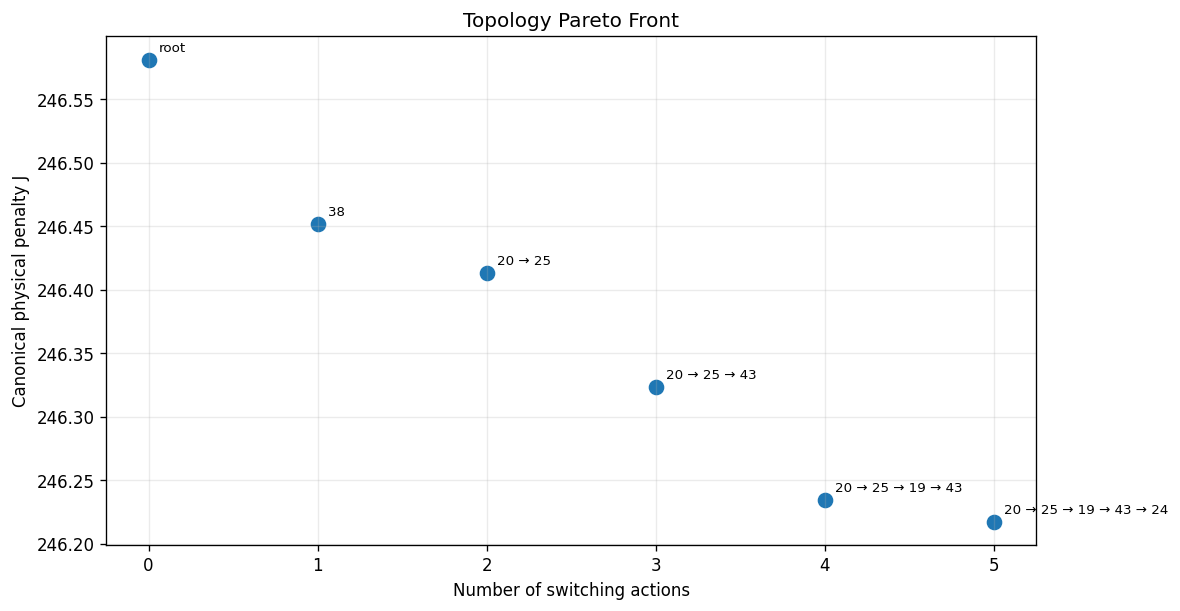

In [117]:
fig, ax = plt.subplots()

ax.scatter(pareto["switches"], pareto["J"], s=70)

for _, row in pareto.iterrows():
    ax.annotate(
        row["sequence"],
        (row["switches"], row["J"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Topology Pareto Front")
ax.set_xlabel("Number of switching actions")
ax.set_ylabel("Canonical physical penalty J")
plt.show()

## 8. Physical epsilon selection

In [118]:
root_J = float(pareto.loc[pareto["switches"] == 0, "J"].min())
best_J = float(pareto["J"].min())
epsilon = 0.01

epsilon = 0.01

physical_tolerance = epsilon * abs(root_J)
threshold_J = best_J + physical_tolerance

near_optimal = pareto[
    pareto["J"] <= threshold_J + 1e-9
]

print("Root J:", root_J)
print("Best J:", best_J)
print("1% threshold:", threshold_J)
near_optimal.sort_values(["switches", "J"])

Root J: 246.581235284856
Best J: 246.21754204755132
1% threshold: 248.68335440039988


,sequence,switches,J,solved,max_loading_percent,hard_overloads
0,root,0,246.581235,False,142.797312,1
1,38,1,246.451673,False,142.778803,1
2,20 → 25,2,246.412986,False,142.772543,1
3,20 → 25 → 43,3,246.323820,False,142.760543,1
4,20 → 25 → 19 → 43,4,246.234632,False,142.747800,1
5,20 → 25 → 19 → 43 → 24,5,246.217542,False,142.745364,1


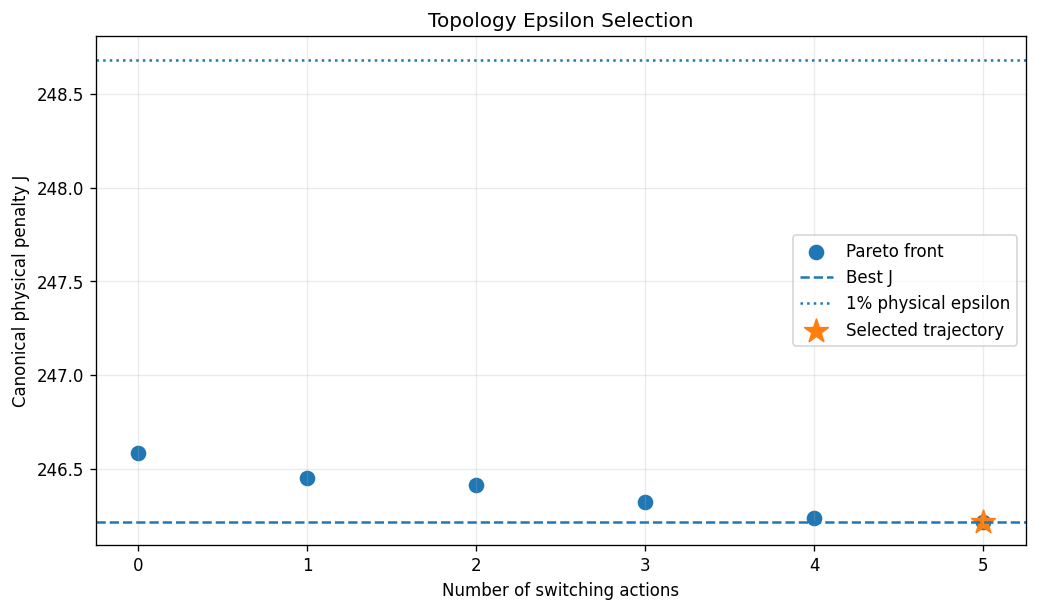

In [119]:
fig, ax = plt.subplots()

ax.scatter(pareto["switches"], pareto["J"], s=70, label="Pareto front")
ax.axhline(best_J, linestyle="--", label="Best J")
ax.axhline(threshold_J, linestyle=":", label="1% physical epsilon")
ax.scatter(
    result.selected_switch_count,
    result.selected_safety,
    marker="*",
    s=220,
    label="Selected trajectory",
)

ax.set_title("Topology Epsilon Selection")
ax.set_xlabel("Number of switching actions")
ax.set_ylabel("Canonical physical penalty J")
ax.legend()
plt.show()

## 9. Redispatch candidates

In [96]:
from grid_topology_ai.search.teacher import _terminal_candidate

terminal_candidates = [
    candidate
    for node in result.pareto_front
    if (candidate := _terminal_candidate(node)) is not None
]

redispatch = pd.DataFrame(
    [
        {
            "sequence": sequence(candidate.node),
            "switches": switch_count(candidate.node),
            "J": candidate.node.safety_score,
            "redispatch_l1_mw": candidate.redispatch_l1_mw,
        }
        for candidate in terminal_candidates
    ],
    columns=[
        "sequence",
        "switches",
        "J",
        "redispatch_l1_mw",
    ],
)

redispatch.sort_values(["switches", "redispatch_l1_mw"])

,sequence,switches,J,redispatch_l1_mw


## 10. Redispatch Pareto front

In [97]:
from grid_topology_ai.search.teacher import _select_terminal_candidate

if len(terminal_candidates) > 0:
    selected, terminal_front, terminal_pool = _select_terminal_candidate(
        terminal_candidates,
        relative_epsilon=0.01,
        absolute_epsilon_mw=1.0,
    )

    redispatch_front = pd.DataFrame([
        {
            "sequence": sequence(candidate.node),
            "switches": switch_count(candidate.node),
            "J": candidate.node.safety_score,
            "redispatch_l1_mw": candidate.redispatch_l1_mw,
            "selected": candidate is selected,
        }
        for candidate in terminal_front
    ])

    best_R = redispatch_front["redispatch_l1_mw"].min()
    threshold_R = best_R * 1.01 + 1.0

    redispatch_front
else:
    redispatch_front = pd.DataFrame(
        columns=[
            "sequence",
            "switches",
            "J",
            "redispatch_l1_mw",
            "selected",
        ]
    )

    print("No validated redispatch candidates for this scenario.")

No validated redispatch candidates for this scenario.


IndexError: single positional indexer is out-of-bounds

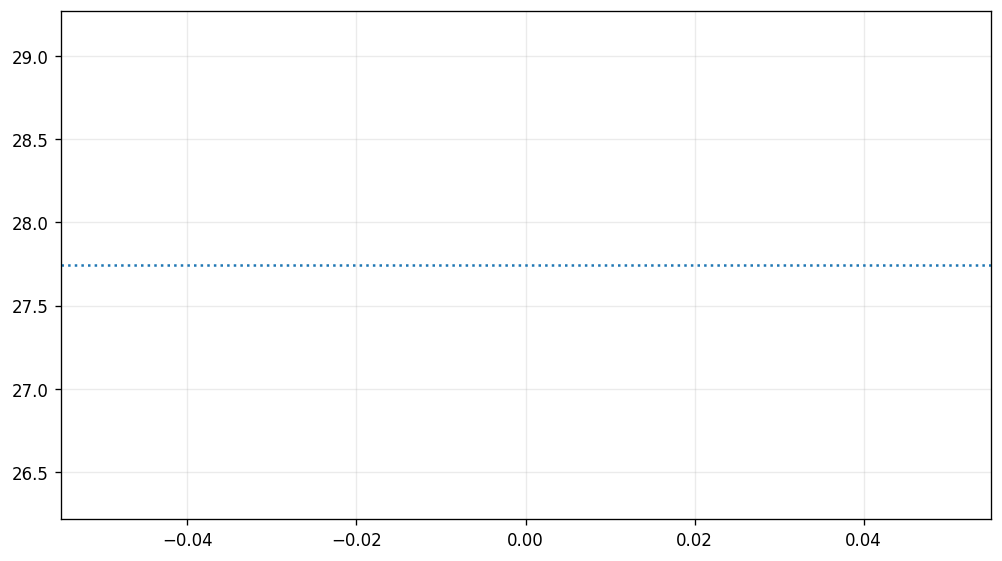

In [98]:
fig, ax = plt.subplots()

ax.scatter(
    redispatch_front["switches"],
    redispatch_front["redispatch_l1_mw"],
    s=70,
)

ax.axhline(threshold_R, linestyle=":", label="Redispatch epsilon")

selected_row = redispatch_front[redispatch_front["selected"]].iloc[0]
ax.scatter(
    selected_row["switches"],
    selected_row["redispatch_l1_mw"],
    marker="*",
    s=220,
    label="Selected trajectory",
)

for _, row in redispatch_front.iterrows():
    ax.annotate(
        row["sequence"],
        (row["switches"], row["redispatch_l1_mw"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Redispatch Pareto Front")
ax.set_xlabel("Number of switching actions")
ax.set_ylabel(r"Validated $R_{L1}$, MW")
ax.legend()
plt.show()

## 11. J vs redispatch

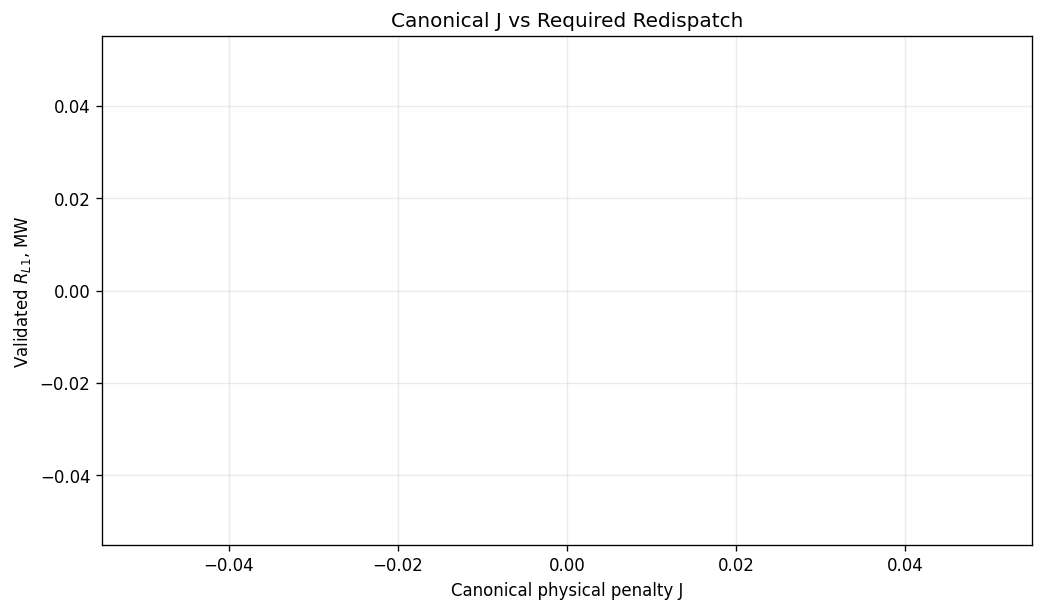

In [99]:
fig, ax = plt.subplots()

ax.scatter(
    redispatch_front["J"],
    redispatch_front["redispatch_l1_mw"],
    s=80,
)

for _, row in redispatch_front.iterrows():
    ax.annotate(
        f'{int(row["switches"])} switches',
        (row["J"], row["redispatch_l1_mw"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Canonical J vs Required Redispatch")
ax.set_xlabel("Canonical physical penalty J")
ax.set_ylabel(r"Validated $R_{L1}$, MW")
plt.show()

## 12. Final redispatch-aware selection

In [100]:
from grid_topology_ai.search.teacher import _redispatch_aware_selection

final_result, diagnostics = _redispatch_aware_selection(
    result,
    task_config={
        "terminal_redispatch_relative_epsilon": 0.01,
        "terminal_redispatch_absolute_epsilon_mw": 1.0,
        "min_meaningful_safety_improvement": 1.0,
    },
)

comparison = pd.DataFrame([
    {
        "stage": "Topology Pareto",
        "sequence": sequence(result.best_node),
        "switches": result.selected_switch_count,
        "J": result.selected_safety,
    },
    {
        "stage": "Redispatch-aware",
        "sequence": sequence(final_result.best_node),
        "switches": final_result.selected_switch_count,
        "J": final_result.selected_safety,
    },
])

comparison

,stage,sequence,switches,J
0,Topology Pareto,20 → 138,2,246.497709
1,Redispatch-aware,root,0,246.581235


## 13. Selected redispatch diagnostics

In [93]:
from grid_topology_ai.physics.redispatch import run_minimal_ac_redispatch

final_state = final_result.best_node.env.current_state
redispatch_result = run_minimal_ac_redispatch(
    final_result.best_node.env.backend,
    final_state,
)

pd.Series(redispatch_result.diagnostics())

redispatch_attempted                                                              True
redispatch_opf_success                                                            True
redispatch_validated                                                              True
redispatch_l1_mw                                                             26.477307
redispatch_up_mw                                                             19.104729
redispatch_down_mw                                                            7.372578
redispatch_max_generator_delta_mw                                             2.433308
redispatch_message                   AC redispatch satisfies the strict physical co...
dtype: object

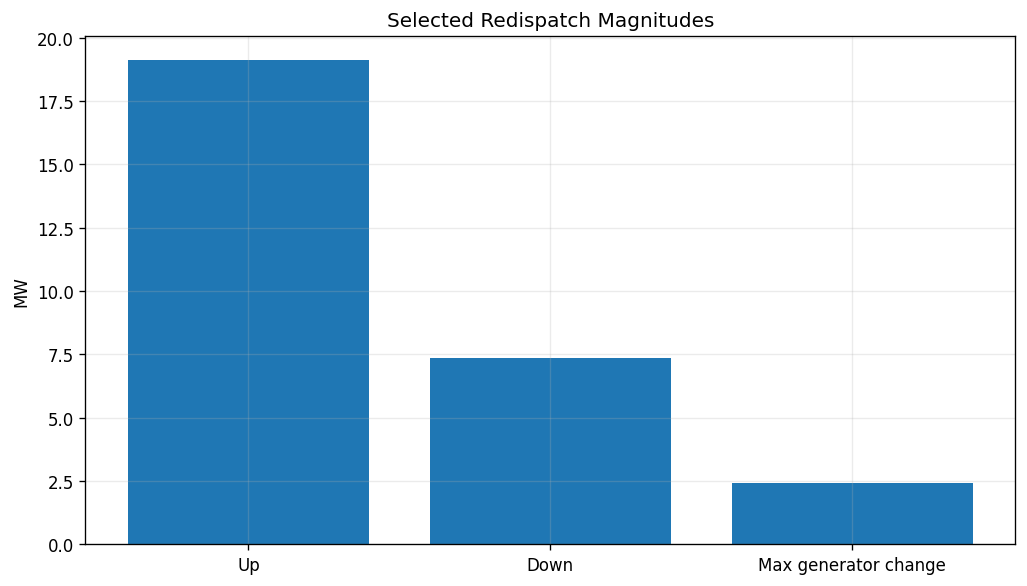

In [94]:
diagnostics_plot = pd.Series({
    "Up": redispatch_result.redispatch_up_mw,
    "Down": redispatch_result.redispatch_down_mw,
    "Max generator change": redispatch_result.redispatch_max_generator_delta_mw,
})

fig, ax = plt.subplots()
ax.bar(diagnostics_plot.index, diagnostics_plot.values)
ax.set_title("Selected Redispatch Magnitudes")
ax.set_ylabel("MW")
plt.show()